# Heat Flow vs TV Flow

We update 1D and 2D comparisons with reverse overlay and longer 2D evolution.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

from scipy.ndimage import gaussian_filter

n = 420
t = np.linspace(0,1,n)
u0 = np.sin(2*np.pi*3*t) + 0.9*(t>0.35) - 0.7*(t>0.68)

def heat_1d(u, dt=0.12, steps=85):
    U=[u.copy()]
    for _ in range(steps):
        lap = np.roll(u,1)+np.roll(u,-1)-2*u
        u = u + dt*lap
        U.append(u.copy())
    return np.array(U)


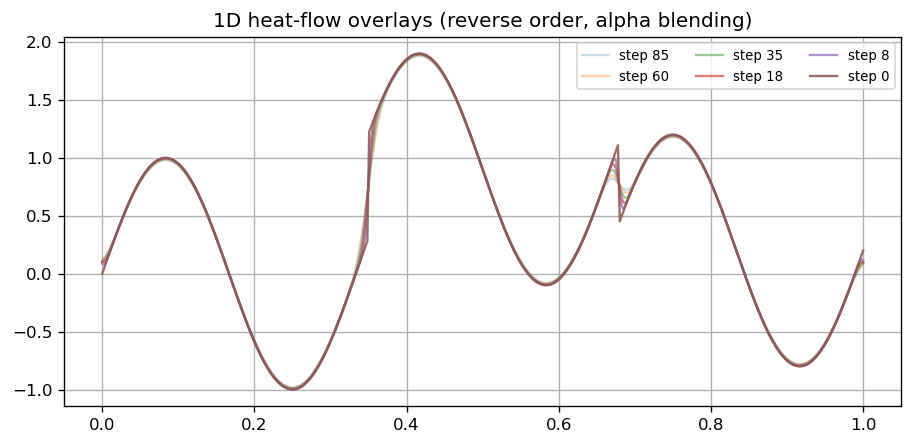

In [2]:
U = heat_1d(u0.copy())
pick = [0, 8, 18, 35, 60, 85]
fig, ax = plt.subplots(figsize=(9,4))
for k, i in enumerate(pick[::-1]):  # reverse overlay order
    ax.plot(t, U[i], lw=1.4, alpha=0.25 + 0.12*k, label=f'step {i}')
ax.set_title('1D heat-flow overlays (reverse order, alpha blending)')
ax.legend(ncol=3, fontsize=8)
plt.show()


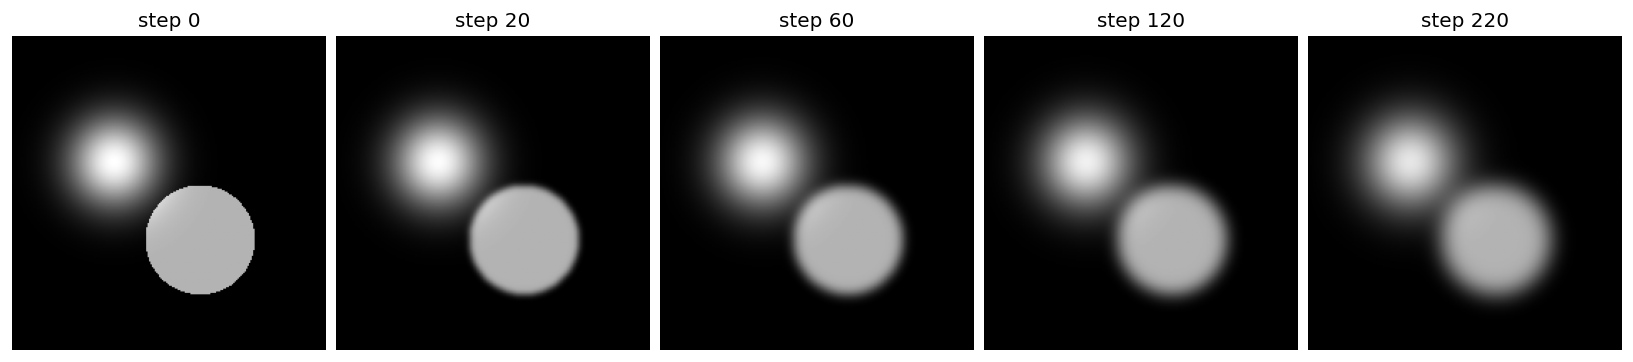

In [3]:
# 2D longer-time flow
m = 220
x = np.linspace(-1,1,m)
X, Y = np.meshgrid(x, x)
img = np.exp(-((X+0.35)**2 + (Y+0.2)**2)/0.08) + 0.7*(np.sqrt((X-0.2)**2+(Y-0.3)**2) < 0.35)
img = (img - img.min())/(img.max()-img.min())

u = img.copy()
sn = [u.copy()]
for k in range(220):
    lap = (np.roll(u,1,0)+np.roll(u,-1,0)+np.roll(u,1,1)+np.roll(u,-1,1)-4*u)
    u = np.clip(u + 0.12*lap, 0, 1)
    if k in [20, 60, 120, 219]:
        sn.append(u.copy())

fig, axes = plt.subplots(1,5, figsize=(13.5,3), constrained_layout=True)
for ax, U, s in zip(axes, sn, [0,20,60,120,220]):
    ax.imshow(U, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'step {s}')
    ax.axis('off')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
